
# Exploratory Data Analysis (EDA)

- Data Overview
- Univariate Analysis
- Bivariate Analysis
- Multivariate Analysis
- Feature Engineering
- Business Insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

master_df = pd.read_csv('master_dataframe.csv')

# Data Overview

In [2]:
master_df.shape

(119143, 40)

In [3]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  order_item_id                 

In [4]:
master_df.dtypes

order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
customer_unique_id                object
customer_zip_code_prefix           int64
customer_city                     object
customer_state                    object
order_item_id                    float64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
payment_sequential               float64
payment_type                      object
payment_installments             float64
payment_value                    float64
product_category_name             object
product_name_lenght              float64
product_descript

In [5]:
missing = master_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

order_delivered_customer_date    3421
product_category_name_english    2567
order_delivered_carrier_date     2086
review_answer_timestamp           997
review_comment_message            997
review_score                      997
review_id                         997
review_comment_title              997
review_creation_date              997
product_category_name             833
order_item_id                     833
seller_id                         833
product_id                        833
shipping_limit_date               833
price                             833
seller_city                       833
seller_zip_code_prefix            833
product_width_cm                  833
product_height_cm                 833
product_length_cm                 833
product_name_lenght               833
freight_value                     833
product_description_lenght        833
product_photos_qty                833
product_weight_g                  833
seller_state                      833
order_approv

In [6]:
master_df.memory_usage()

Index                               132
order_id                         953144
customer_id                      953144
order_status                     953144
order_purchase_timestamp         953144
order_approved_at                953144
order_delivered_carrier_date     953144
order_delivered_customer_date    953144
order_estimated_delivery_date    953144
customer_unique_id               953144
customer_zip_code_prefix         953144
customer_city                    953144
customer_state                   953144
order_item_id                    953144
product_id                       953144
seller_id                        953144
shipping_limit_date              953144
price                            953144
freight_value                    953144
payment_sequential               953144
payment_type                     953144
payment_installments             953144
payment_value                    953144
product_category_name            953144
product_name_lenght              953144


In [7]:
master_df.describe()

,customer_zip_code_prefix,order_item_id,price,freight_value,payment_sequential,payment_installments,payment_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,review_score
count,119143.000000,118310.000000,118310.000000,118310.000000,119140.000000,119140.000000,119140.000000,118310.000000,118310.000000,118310.000000,118310.000000,118310.000000,118310.000000,118310.000000,118310.000000,118146.000000
mean,35033.451298,1.196543,120.646603,20.032387,1.094737,2.941246,172.735135,48.799746,783.209272,2.187753,2112.012002,30.264255,16.619094,23.074279,24442.410413,4.015582
std,29823.198969,0.699489,184.109691,15.836850,0.730141,2.777848,267.776077,9.964369,648.254189,1.711055,3786.419544,16.188144,13.452529,11.748214,27573.004511,1.400436
min,1003.000000,1.000000,0.850000,0.000000,1.000000,0.000000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1001.000000,1.000000
25%,11250.000000,1.000000,39.900000,13.080000,1.000000,1.000000,60.850000,43.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6429.000000,4.000000
50%,24240.000000,1.000000,74.900000,16.280000,1.000000,2.000000,108.160000,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000,13660.000000,5.000000
75%,58475.000000,1.000000,134.900000,21.180000,1.000000,4.000000,189.240000,57.000000,977.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,27972.000000,5.000000
max,99990.000000,21.000000,6735.000000,409.680000,29.000000,24.000000,13664.080000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99730.000000,5.000000


In [8]:
master_df.describe(include='object')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,...,payment_type,product_category_name,seller_city,seller_state,review_id,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
count,119143,119143,119143,119143,118966,117057,115722,119143,119143,119143,...,119140,118310,118310,118310,118146,118146,118146,118146,118146,116576
unique,99441,99441,8,98875,90733,81018,95664,459,96096,4119,...,5,74,611,23,98410,4528,36160,636,98248,71
top,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,2017-08-08 20:26:31,2017-08-08 20:43:31,2017-08-10 11:58:14,2017-08-14 12:46:18,2017-12-20,9a736b248f67d166d2fbb006bcb877c3,Sao Paulo,...,credit_card,cama_mesa_banho,Sao Paulo,SP,eef5dbca8d37dfce6db7d7b16dd0525e,No Title,No Review,2017-12-19 00:00:00,2017-08-17 22:17:55,bed_bath_table
freq,63,63,115723,63,63,63,63,663,75,18875,...,87776,11988,29293,84377,63,104157,67901,547,63,11988


In [9]:
missing_percent = (
    master_df.isnull().sum() /
    len(master_df)
) * 100

missing_percent = (
    missing_percent[missing_percent > 0]
    .sort_values(ascending=False)
)

missing_percent

order_delivered_customer_date    2.871339
product_category_name_english    2.154554
order_delivered_carrier_date     1.750837
review_answer_timestamp          0.836810
review_comment_message           0.836810
review_score                     0.836810
review_id                        0.836810
review_comment_title             0.836810
review_creation_date             0.836810
product_category_name            0.699160
order_item_id                    0.699160
seller_id                        0.699160
product_id                       0.699160
shipping_limit_date              0.699160
price                            0.699160
seller_city                      0.699160
seller_zip_code_prefix           0.699160
product_width_cm                 0.699160
product_height_cm                0.699160
product_length_cm                0.699160
product_name_lenght              0.699160
freight_value                    0.699160
product_description_lenght       0.699160
product_photos_qty               0

In [10]:
master_df.duplicated().sum()

np.int64(0)

In [11]:
master_df.nunique().sort_values()

payment_type                         5
review_score                         5
order_status                         8
product_photos_qty                  19
order_item_id                       21
seller_state                        23
payment_installments                24
customer_state                      27
payment_sequential                  29
product_name_lenght                 66
product_category_name_english       71
product_category_name               74
product_width_cm                    95
product_length_cm                   99
product_height_cm                  102
order_estimated_delivery_date      459
seller_city                        611
review_creation_date               636
product_weight_g                  2204
seller_zip_code_prefix            2246
product_description_lenght        2960
seller_id                         3095
customer_city                     4119
review_comment_title              4528
price                             5968
freight_value            

# #Univariate Analysis

In [12]:
master_df['order_status'].value_counts()

order_status
delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: count, dtype: int64

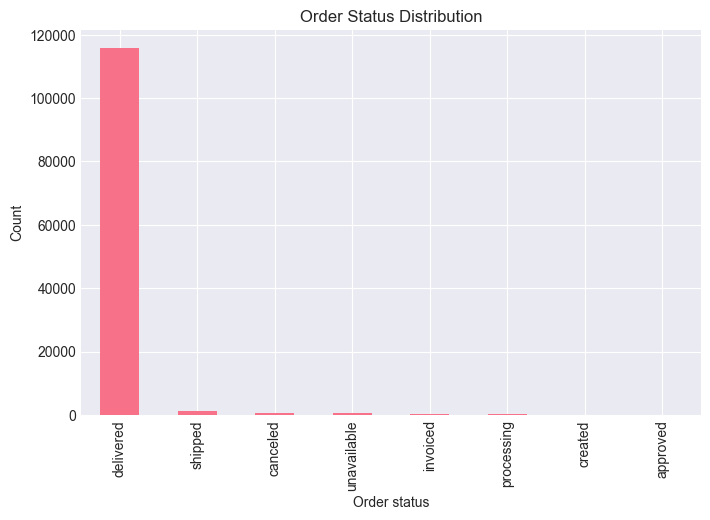

In [13]:
master_df['order_status'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)
plt.title('Order Status Distribution')
plt.xlabel('Order status')
plt.ylabel('Count')
plt.show()

In [14]:
master_df['payment_type'].value_counts()

payment_type
credit_card    87776
boleto         23190
voucher         6465
debit_card      1706
not_defined        3
Name: count, dtype: int64

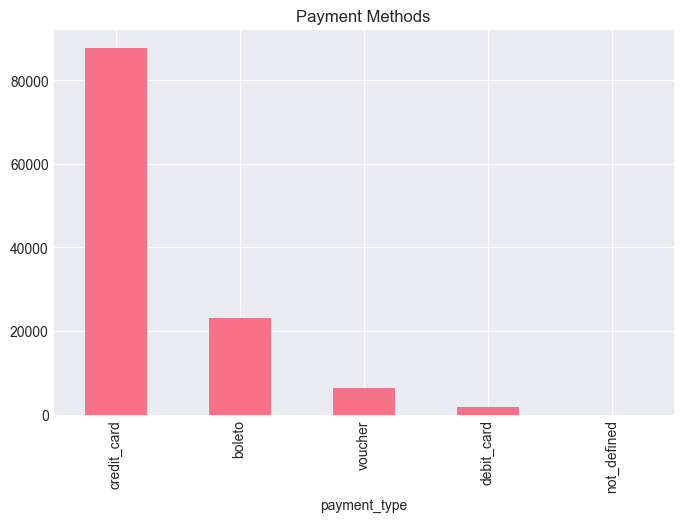

In [15]:
master_df['payment_type'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Payment Methods')
plt.show()

In [16]:
master_df['review_score'].value_counts().sort_index()

review_score
1.0    15428
2.0     4162
3.0     9894
4.0    22319
5.0    66343
Name: count, dtype: int64

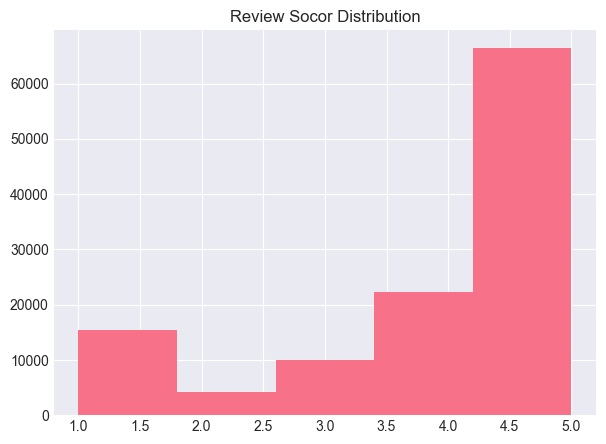

In [17]:
master_df['review_score'].hist(
    bins=5,
    figsize=(7,5)

)

plt.title('Review Socor Distribution')
plt.show()

In [18]:
master_df['product_category_name_english'] \
.value_counts() \
.head(10)

product_category_name_english
bed_bath_table           11988
health_beauty            10032
sports_leisure            9004
furniture_decor           8832
computers_accessories     8150
housewares                7380
watches_gifts             6213
telephony                 4726
garden_tools              4590
auto                      4400
Name: count, dtype: int64

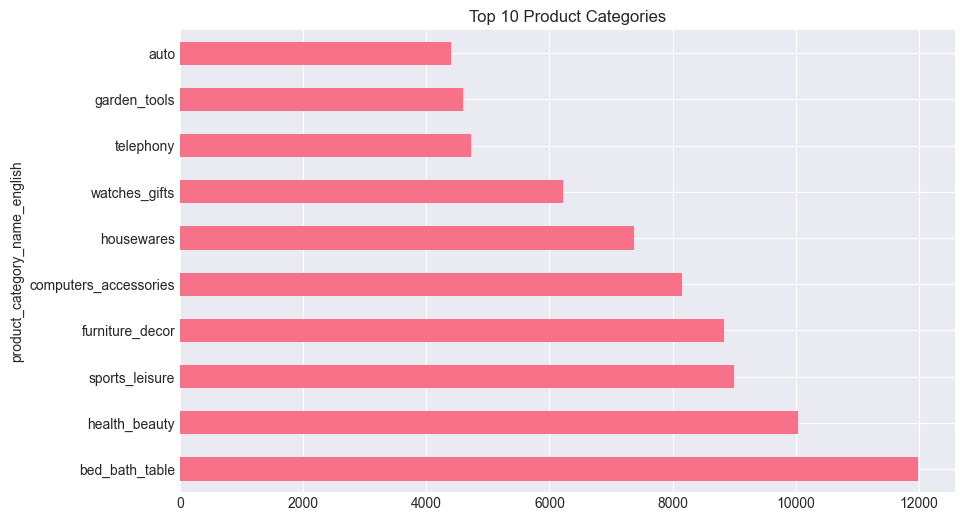

In [19]:
master_df['product_category_name_english'] \
.value_counts() \
.head(10) \
.plot(kind='barh',figsize=(10,6))

plt.title('Top 10 Product Categories')
plt.show()

In [20]:
master_df['price'].describe()

count    118310.000000
mean        120.646603
std         184.109691
min           0.850000
25%          39.900000
50%          74.900000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

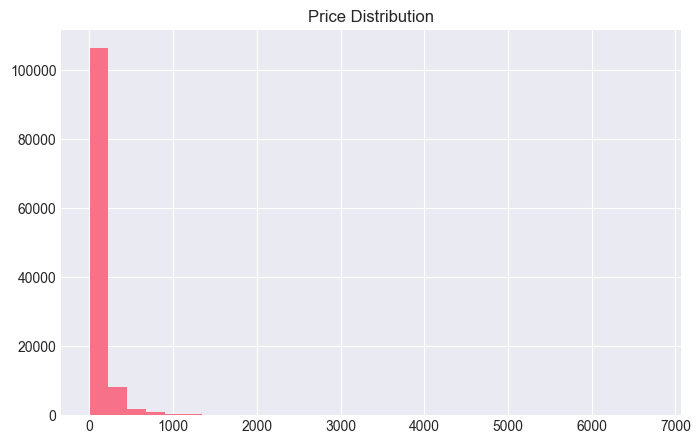

In [21]:
master_df['price'].hist(
    bins=30,
    figsize=(8,5)
)

plt.title('Price Distribution')
plt.show()

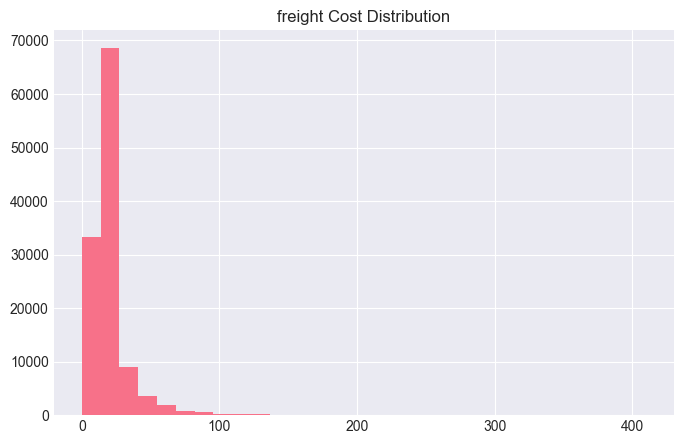

In [22]:
master_df['freight_value'].hist(
    bins=30,
    figsize=(8,5)
)

plt.title('freight Cost Distribution')
plt.show()

# Complete these analyses:

- Data Overview
- Order Status
- Payment Type
- Review Score
- Product Category
- Price Distribution
- Freight Distribution

# #Bivariate Analysis


In [23]:
# Which state generate the highest revenue
state_seles = (
    master_df.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False)
)

state_seles.head(10)

customer_state
SP    7726078.35
RJ    2795615.67
MG    2351221.09
RS    1160175.66
PR    1079795.49
BA     805070.98
SC     801276.45
GO     520481.65
DF     438095.32
ES     408611.64
Name: payment_value, dtype: float64

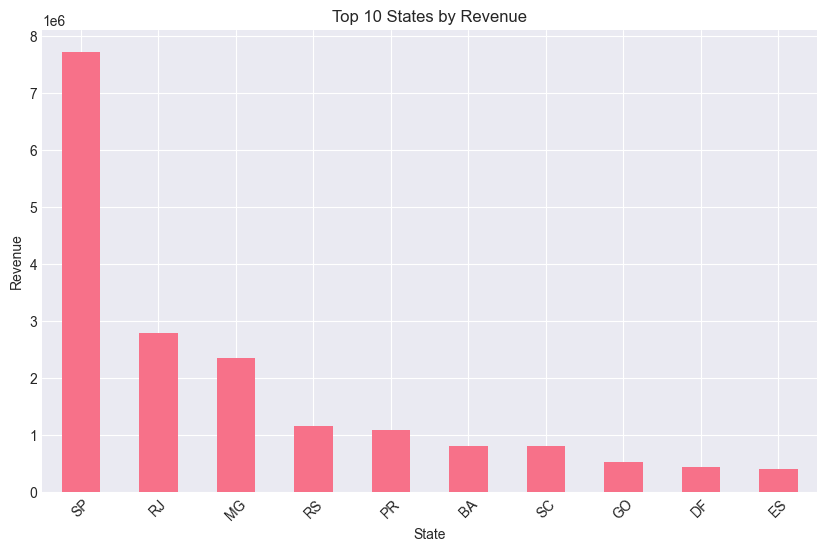

In [24]:
plt.figure(figsize=(10,6))

state_seles.head(10).plot(kind='bar')

plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

### Insight

- State SP generated the highest revenue.
- The top 10 states contribute a significant portion of total sales.
- Marketing campaigns can focus on high-performing regions while exploring opportunities in lower-performing states.

In [25]:
# Which product categorties generate gihgest eevenue.

category_seles = (
    master_df.groupby('product_category_name_english')['payment_value'].sum().sort_values(ascending=False)
)

category_seles.head(10)

product_category_name_english
bed_bath_table           1743998.80
health_beauty            1662963.59
computers_accessories    1599481.06
furniture_decor          1443963.61
watches_gifts            1430553.48
sports_leisure           1400223.07
housewares               1097900.09
auto                      855095.68
garden_tools              840721.59
cool_stuff                781933.97
Name: payment_value, dtype: float64

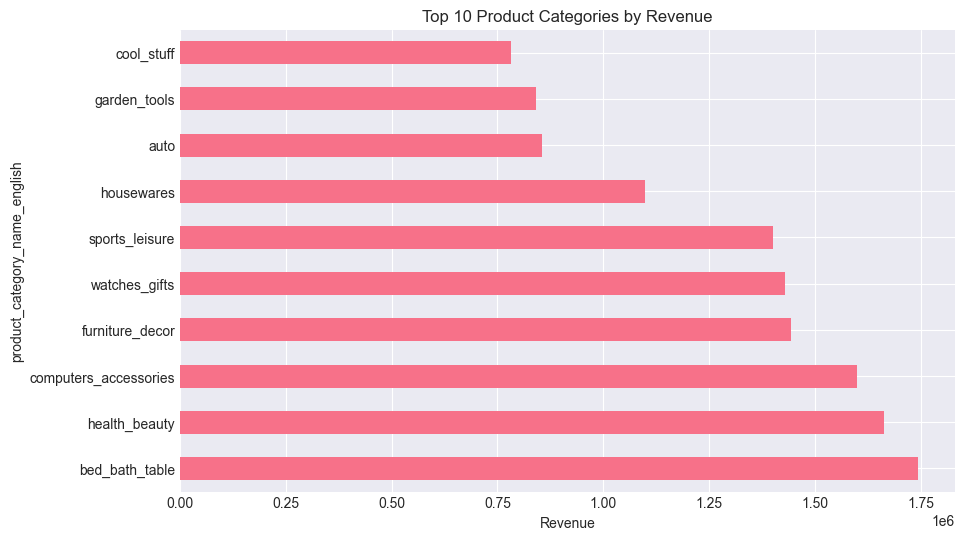

In [26]:
plt.figure(figsize=(10,6))

category_seles.head(10).plot(kind='barh')

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue')

plt.show()

### Insight

- Category bed_bath_table contributes the highest revenue.
- The company should prioritize inventory and promotions for these categories.

In [27]:
# which payment mathods used for high-value oders.

payment_analysis = (
    master_df.groupby('payment_type')['payment_value'].mean().sort_values(ascending=False)
)

payment_analysis


payment_type
credit_card    179.723963
boleto         177.271270
debit_card     150.864531
voucher         67.427353
not_defined      0.000000
Name: payment_value, dtype: float64

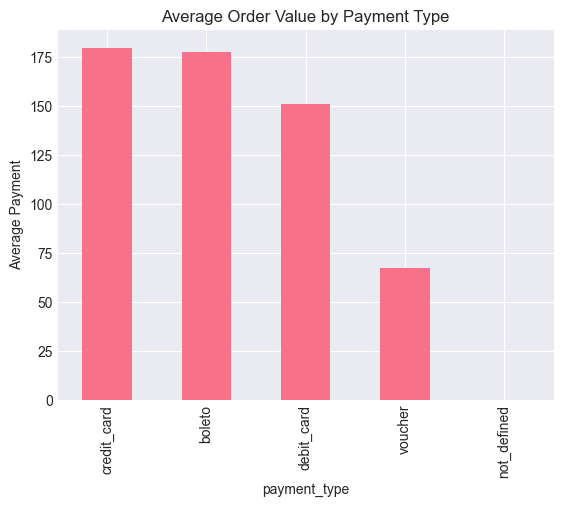

In [28]:
plt.Figure(figsize=(8,5))

payment_analysis.plot(kind='bar')

plt.title('Average Order Value by Payment Type')

plt.ylabel('Average Payment')

plt.show()

### Insight

- Credit cards tend to have the highest average payment value.
- Customers using vouchers usually make smaller purchases.

In [29]:
# which sellers generate highest revenue

seller_seles = (
    master_df.groupby('seller_id')['payment_value'].sum().sort_values(ascending=False)
)
seller_seles.head(10)

seller_id
7c67e1448b00f6e969d365cea6b010ab    512645.19
1025f0e2d44d7041d6cf58b6550e0bfa    312456.49
4a3ca9315b744ce9f8e9374361493884    306138.80
1f50f920176fa81dab994f9023523100    291918.98
53243585a1d6dc2643021fd1853d8905    284903.08
da8622b14eb17ae2831f4ac5b9dab84a    276578.63
4869f7a5dfa277a7dca6462dcf3b52b2    264166.12
955fee9216a65b617aa5c0531780ce60    236414.48
fa1c13f2614d7b5c4749cbc52fecda94    206513.23
7e93a43ef30c4f03f38b393420bc753a    185134.21
Name: payment_value, dtype: float64

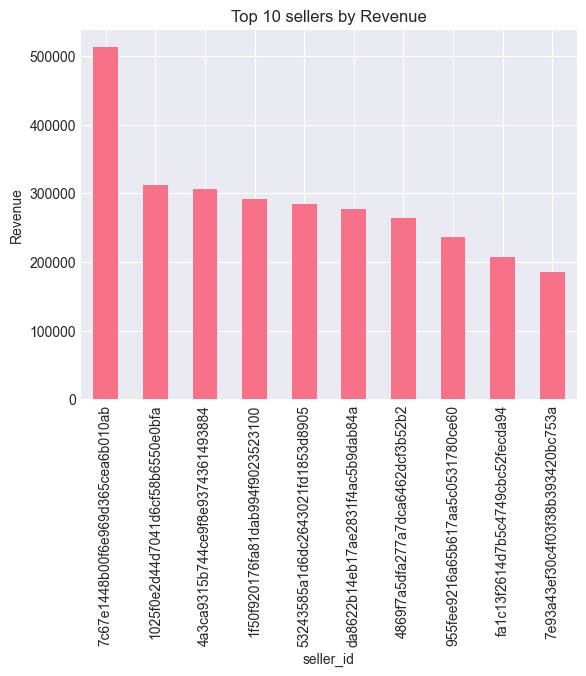

In [30]:
plt.Figure(figsize=(10,6))

seller_seles.head(10).plot(kind='bar')

plt.title('Top 10 sellers by Revenue')

plt.ylabel('Revenue')

plt.show()


### Insight

- A small number of sellers contribute a large share of revenue.
- High-performing sellers can be rewarded through loyalty programs.

In [31]:
# Do higher prices receive better reviews

price_review = (
    master_df.groupby('review_score')['price'].mean()
)

price_review

review_score
1.0    127.865836
2.0    116.824840
3.0    109.145154
4.0    119.025420
5.0    121.296862
Name: price, dtype: float64

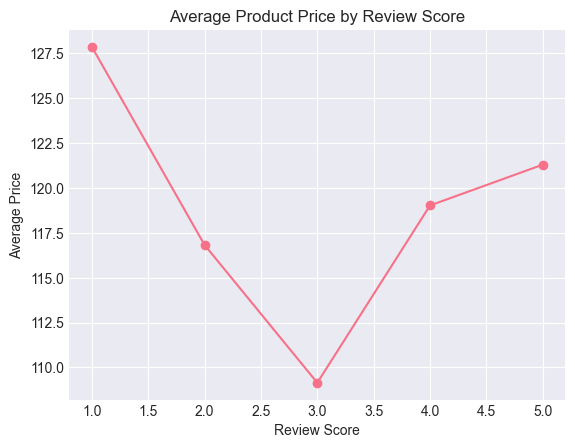

In [32]:
plt.Figure(figsize=(8,5))

price_review.plot(marker='o')

plt.title('Average Product Price by Review Score')
plt.xlabel('Review Score')
plt.ylabel('Average Price')

plt.grid(True)

plt.show()

### Insight

- Higher-priced products do not always receive higher ratings.
- Customer satisfaction depends on product quality and delivery experience, not just price.

In [33]:
# which states have highest average review score

state_review = (
    master_df.groupby('customer_state')['review_score'].mean().sort_values(ascending=False)
)

state_review.head(10)

customer_state
AP    4.240964
TO    4.138643
SP    4.108609
AC    4.094737
PR    4.087130
AM    4.070175
MG    4.068543
MS    4.054651
RN    4.049296
RS    4.027184
Name: review_score, dtype: float64

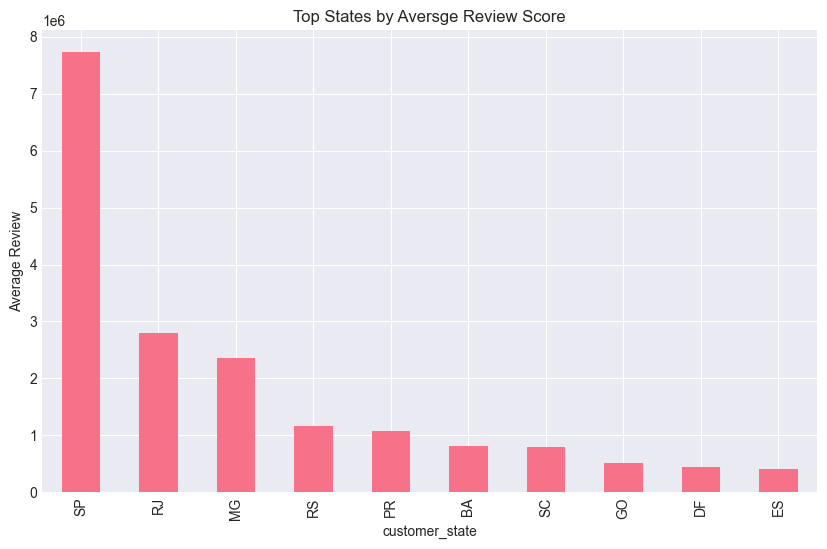

In [34]:
plt.figure(figsize=(10,6))

state_seles.head(10).plot(kind='bar')

plt.title('Top States by Aversge Review Score')
plt.ylabel('Average Review')

plt.show()

In [35]:
# Which product categorise receive the bast reviews

category_reviews = (
    master_df.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=False)
)

category_reviews.head(10)

product_category_name_english
cds_dvds_musicals                        4.642857
fashion_childrens_clothes                4.500000
books_general_interest                   4.438503
books_imported                           4.419355
flowers                                  4.419355
costruction_tools_tools                  4.415842
books_technical                          4.375465
food_drink                               4.324138
small_appliances_home_oven_and_coffee    4.320513
luggage_accessories                      4.295945
Name: review_score, dtype: float64

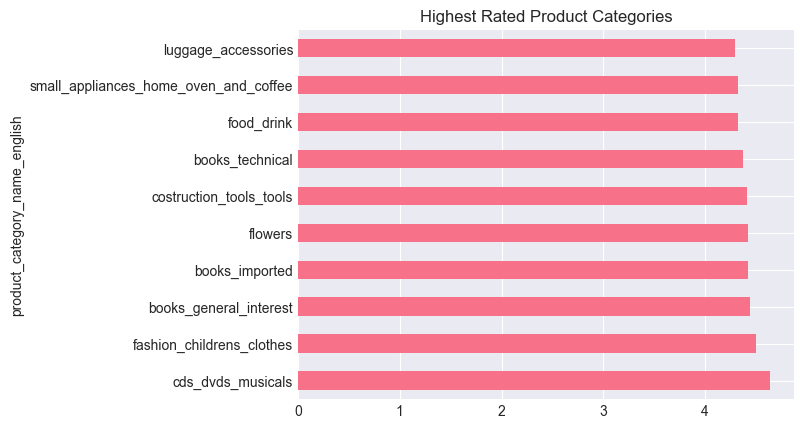

In [36]:
plt.Figure(figsize=(10,8))

category_reviews.head(10).plot(kind='barh')

plt.title('Highest Rated Product Categories')

plt.show()

In [37]:
# monthly revenue trend

master_df['order_purchase_timestamp'] = pd.to_datetime(
    master_df['order_purchase_timestamp']
)

master_df['YearMonth'] = (
    master_df['order_purchase_timestamp'].dt.to_period('M')
)

In [38]:
monthly_seles = (
    master_df.groupby('YearMonth')['payment_value'].sum()
)

monthly_seles

YearMonth
2016-09        388.47
2016-10      76559.05
2016-12         19.62
2017-01     190806.27
2017-02     351848.13
2017-03     547769.84
2017-04     512126.52
2017-05     737425.31
2017-06     613777.41
2017-07     749242.84
2017-08     884168.36
2017-09    1030141.97
2017-10    1046083.41
2017-11    1610581.21
2017-12    1060949.63
2018-01    1425461.40
2018-02    1327338.97
2018-03    1486669.64
2018-04    1500373.12
2018-05    1512010.75
2018-06    1299683.17
2018-07    1362267.08
2018-08    1248942.63
2018-09       4439.54
2018-10        589.67
Freq: M, Name: payment_value, dtype: float64

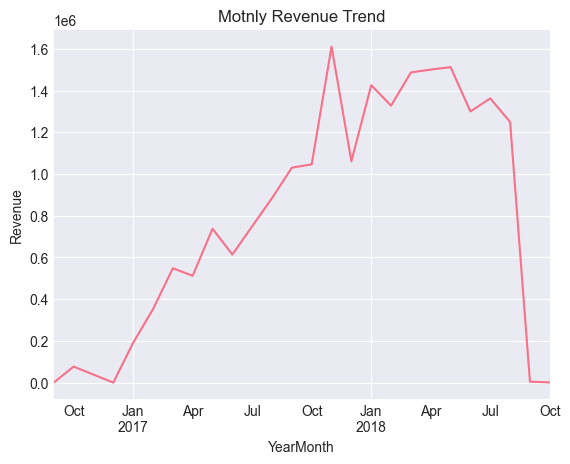

In [39]:
plt.Figure(figsize=(12,6))

monthly_seles.plot()

plt.title('Motnly Revenue Trend')
plt.ylabel('Revenue')

plt.show()

In [40]:
# Which states place the most order

state_order = (
    master_df.groupby('customer_state')['order_id'].count().sort_values(ascending=False)
)

state_order.head(10)

customer_state
SP    50265
RJ    15518
MG    13819
RS     6573
PR     6043
SC     4345
BA     4091
DF     2516
GO     2466
ES     2360
Name: order_id, dtype: int64

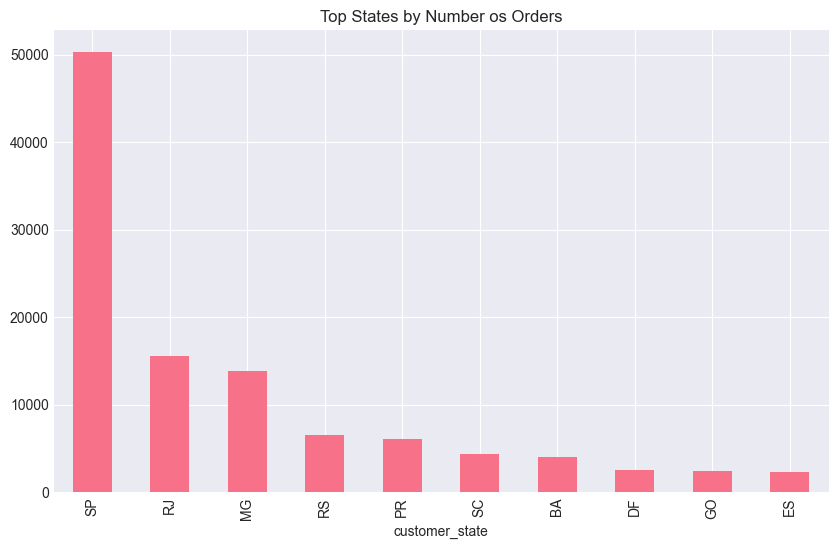

In [41]:
plt.figure(figsize=(10,6))

state_order.head(10).plot(kind='bar')

plt.title('Top States by Number os Orders')

plt.show()

In [42]:
# which payment methods are most popular

payment_count = (
    master_df['payment_type'].value_counts()
)

payment_count

payment_type
credit_card    87776
boleto         23190
voucher         6465
debit_card      1706
not_defined        3
Name: count, dtype: int64

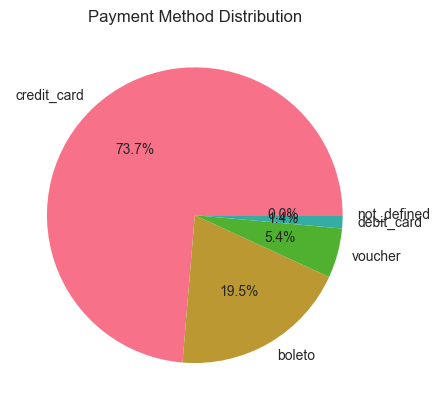

In [43]:
plt.Figure(figsize=(8,5))

payment_count.plot(kind='pie', autopct='%1.1f%%')

plt.ylabel('')
plt.title('Payment Method Distribution')

plt.show()

# #Multivariate Analysis

In [44]:
data_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in data_cols:
    master_df[col] = pd.to_datetime(master_df[col],errors='coerce')

In [45]:
# 1.Delivery Time vs Review Score vs Order Volume

master_df['delivery_date'] = (
    master_df['order_delivered_customer_date'] - master_df['order_purchase_timestamp']).dt.total_seconds() / (24 * 60 * 60)

In [46]:
# Now create delivery-time groups

master_df['delivery_group'] = pd.cut(
    master_df['delivery_date'],
    bins=[0, 5, 10, 15, 20, 30, float('inf')],
    labels=['0-5 days', '6-10 days', '11-15 days',
            '16-20 days', '21-30 days', '30+ days']
)

In [47]:
delivery_review = (
    master_df.groupby('delivery_group',observed=True).agg(
        average_review = ('review_score','mean'),
        order_count = ('order_id','nunique')
    )
)

delivery_review

,average_review,order_count
delivery_group,,
0-5 days,4.372936,13430
6-10 days,4.274711,33052
11-15 days,4.177084,23614
16-20 days,4.048177,12154
21-30 days,3.619764,9673
30+ days,2.246304,4553


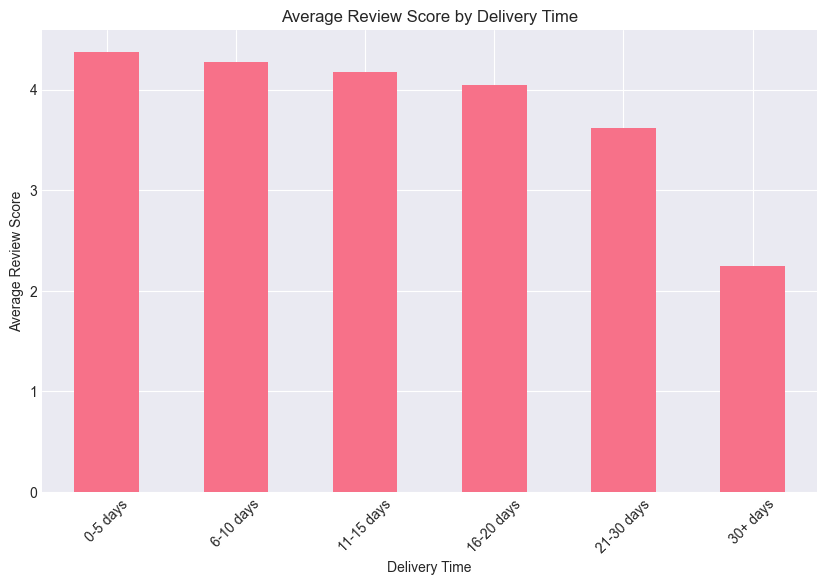

In [48]:
delivery_review['average_review'].plot(kind='bar',figsize=(10,6))

plt.title('Average Review Score by Delivery Time')
plt.xlabel('Delivery Time')
plt.ylabel('Average Review Score')
plt.xticks(rotation=45)
plt.show()

### Insight

The analysis shows that average review scores [increase/decrease/remain relatively stable]
as delivery time increases.

This indicates that delivery speed [does/does not] have a noticeable relationship
with customer satisfaction.

In [49]:
#2. Revenue by State + Product Category
top_states = (
    master_df.groupby('customer_state')['payment_value'].sum().nlargest(5).index
)


In [50]:
state_category_seles = (
    master_df[
        master_df['customer_state'].isin(top_states)
    ]
    .groupby([
        'customer_state',
        'product_category_name_english'
    ])['payment_value'].sum().reset_index()
)

In [51]:
top_categories = (
    state_category_seles
    .groupby('product_category_name_english')['payment_value'].sum().nlargest(10).index
)


In [52]:
plot_data = state_category_seles[
    state_category_seles['product_category_name_english']
    .isin(top_categories)
]

In [53]:
pivot_data = plot_data.pivot(
    index='product_category_name_english',
    columns='customer_state',
    values='payment_value'
)

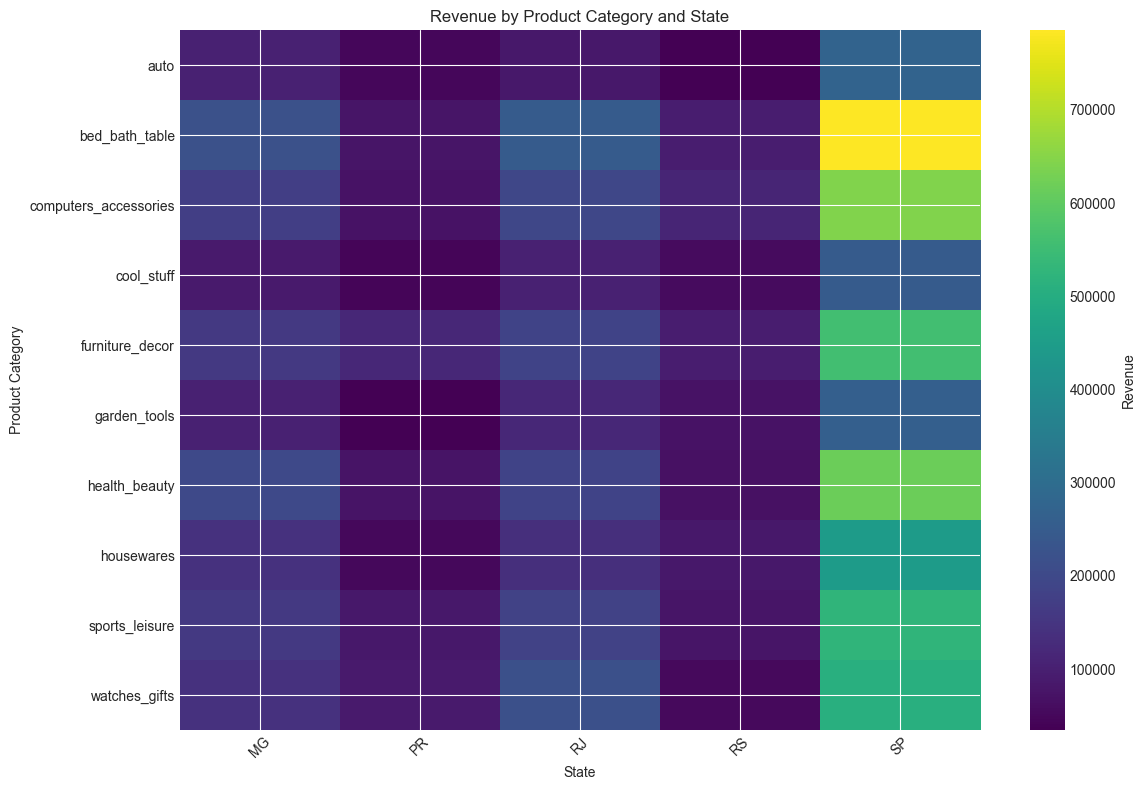

In [54]:
plt.figure(figsize=(12, 8))

plt.imshow(pivot_data.fillna(0), aspect='auto', cmap='viridis')  # Added cmap

plt.colorbar(label='Revenue')

plt.xticks(
    range(len(pivot_data.columns)),
    pivot_data.columns,
    rotation=45  # Optional: rotate for better readability
)

plt.yticks(
    range(len(pivot_data.index)),
    pivot_data.index
)

plt.title('Revenue by Product Category and State')
plt.xlabel('State')
plt.ylabel('Product Category')

plt.tight_layout()  # Adjust spacing
plt.show()

In [55]:
# 3. Payment Type + Review Score + Average Payment

payment_review = (
    master_df.groupby('payment_type').agg(
        average_payment = ('payment_value','mean'),
        average_review = ('review_score','mean'),
        order_count = ('order_id','nunique')
    )
    .sort_values('average_payment',ascending=False)
)

payment_review

,average_payment,average_review,order_count
payment_type,,,
credit_card,179.723963,4.019167,76505
boleto,177.271270,4.008043,19784
debit_card,150.864531,4.146557,1528
voucher,67.427353,3.961796,3866
not_defined,0.000000,1.666667,3


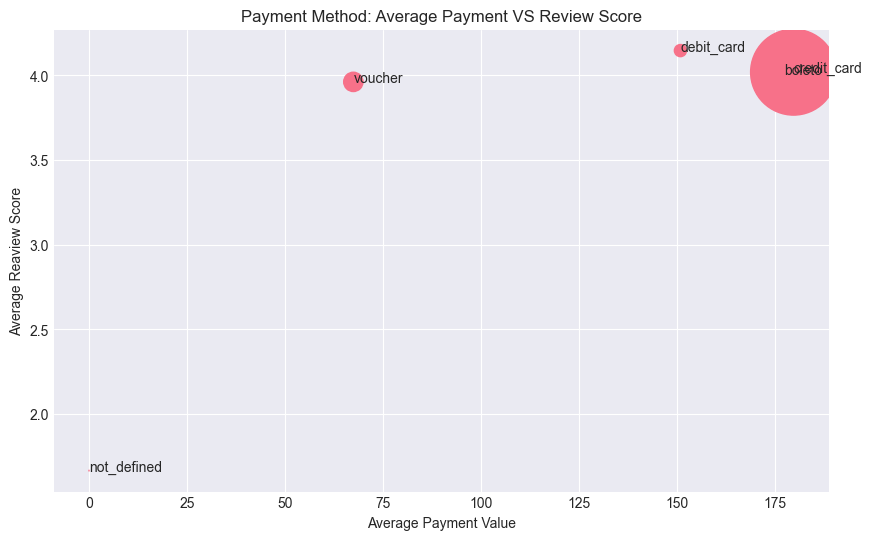

In [56]:
plt.figure(figsize=(10,6))

plt.scatter(
    payment_review['average_payment'],
    payment_review['average_review'],
    s=payment_review['order_count'] / 20
)

for payment, row in payment_review.iterrows():
    plt.annotate(
        payment,
        (row['average_payment'],row['average_review'])
    )

plt.title('Payment Method: Average Payment VS Review Score')
plt.xlabel('Average Payment Value')
plt.ylabel('Average Reaview Score')

plt.show()

In [57]:
# 4. Delivery Time + Review Score + Order Status, delivery performance

delivery_status = (
    master_df.groupby('order_status').agg(
        average_delivery_days = ('delivery_date','mean'),
        average_review = ('review_score','mean'),
        orders = ('order_id','nunique')
    )
)

delivery_status


,average_delivery_days,average_review,orders
order_status,,,
approved,NaN,2.000000,2
canceled,18.532794,1.824658,625
created,NaN,2.333333,5
delivered,12.487705,4.080488,96478
invoiced,NaN,1.650538,314
processing,NaN,1.348649,301
shipped,NaN,1.976884,1107
unavailable,NaN,1.512539,609


Important

Some order statuses may have no delivered date. That's why average_delivery_days can be NaN.

That's not a problem—it tells us that delivery time isn't applicable to those orders

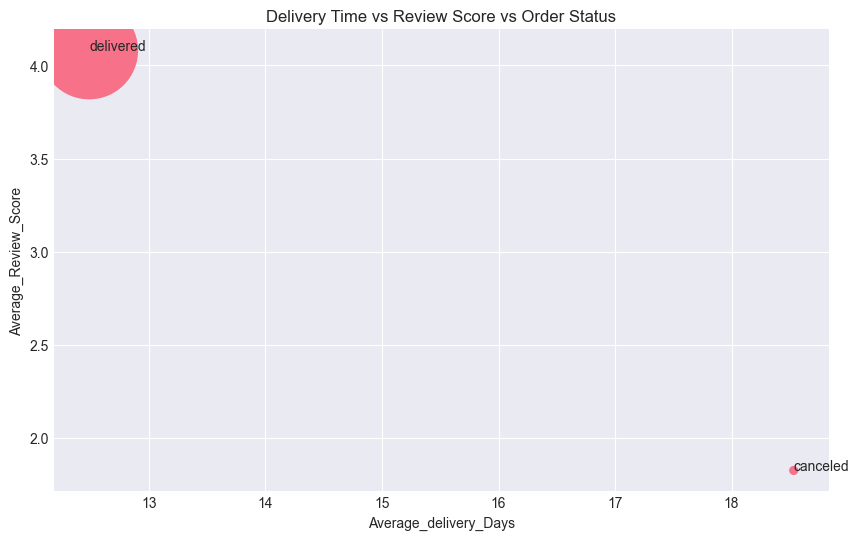

In [58]:
plt.figure(figsize=(10,6))

plt.scatter(
    delivery_status['average_delivery_days'],
    delivery_status['average_review'],
    s=delivery_status['orders'] / 20

)

for status, row in delivery_status.iterrows():
    plt.annotate(
        status,
        (row['average_delivery_days'], row['average_review'])
    )

plt.xlabel('Average_delivery_Days')
plt.ylabel('Average_Review_Score')
plt.title('Delivery Time vs Review Score vs Order Status')

plt.show()

In [59]:
# 5. Price + Freight + Review Score

price_freight_review = master_df[
    ['price','freight_value','review_score']
].dropna()

In [60]:
# Create a correlation matrix

correlation = price_freight_review.corr()

correlation

,price,freight_value,review_score
price,1.000000,0.414018,-0.004492
freight_value,0.414018,1.000000,-0.037013
review_score,-0.004492,-0.037013,1.000000


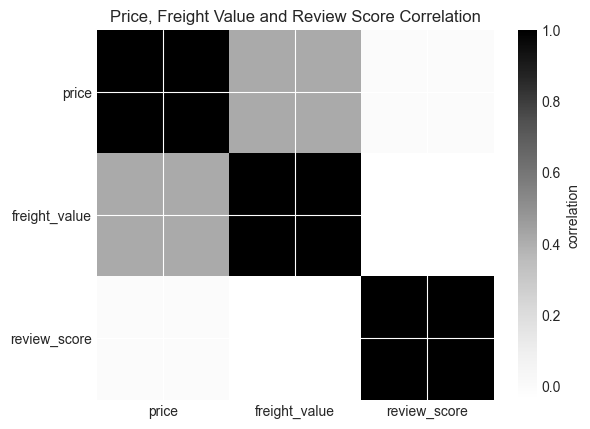

In [61]:
plt.Figure(figsize=(8,6))

plt.imshow(correlation,aspect='auto')

plt.colorbar(label='correlation')

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.yticks(
    range(len(correlation.index)),
    correlation.index
)

plt.title('Price, Freight Value and Review Score Correlation' )

plt.show()

In [62]:
# 6. Monthly Revenue + Order Volume + Review Score
# Creating a month

master_df['order_month'] = (
    master_df['order_purchase_timestamp'].dt.to_period('M')
)


In [63]:
monthly_analysis = (
    master_df.groupby('order_month').agg(
        revenue = ('payment_value','sum'),
        orders = ('order_id', 'nunique'),
        average = ('review_score','mean')
    )

)

monthly_analysis

,revenue,orders,average
order_month,,,
2016-09,388.47,4,1.000000
2016-10,76559.05,324,3.524051
2016-12,19.62,1,5.000000
2017-01,190806.27,800,4.083089
2017-02,351848.13,1780,3.999051
2017-03,547769.84,2682,4.037636
2017-04,512126.52,2404,3.967426
2017-05,737425.31,3700,4.114536
2017-06,613777.41,3245,4.117447


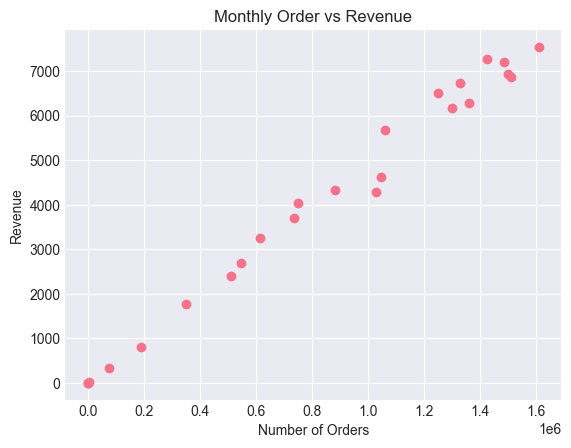

In [64]:
plt.Figure(figsize=(12,6))

plt.scatter(
    monthly_analysis['revenue'],
    monthly_analysis['orders']
)

plt.xlabel('Number of Orders')
plt.ylabel('Revenue')
plt.title('Monthly Order vs Revenue')

plt.show()

In [65]:
# 7. Top Sellers + Revenue + Review Score

seller_analysis = (
    master_df.groupby('seller_id').agg(
        revenue = ('payment_value','sum'),
        orders = ('order_id','nunique'),
        average_review = ('review_score','mean')
    )
)

seller_analysis

,revenue,orders,average_review
seller_id,,,
0015a82c2db000af6aaaf3ae2ecb0532,2748.06,3,3.666667
001cca7ae9ae17fb1caed9dfb1094831,48349.22,200,3.911765
001e6ad469a905060d959994f1b41e4f,267.94,1,1.000000
002100f778ceb8431b7a1020ff7ab48f,2478.33,51,4.033898
003554e2dce176b5555353e4f3555ac8,139.38,1,5.000000
...,...,...,...
ffcfefa19b08742c5d315f2791395ee5,79.52,1,1.000000
ffdd9f82b9a447f6f8d4b91554cc7dd3,3607.52,18,4.285714
ffeee66ac5d5a62fe688b9d26f83f534,2259.55,14,4.214286


In [66]:
# Find the top sellers
top_sellers = (seller_analysis.sort_values('revenue',ascending=False).head(20))

top_sellers

,revenue,orders,average_review
seller_id,,,
7c67e1448b00f6e969d365cea6b010ab,512645.19,982,3.394773
1025f0e2d44d7041d6cf58b6550e0bfa,312456.49,915,3.862116
4a3ca9315b744ce9f8e9374361493884,306138.80,1806,3.801692
1f50f920176fa81dab994f9023523100,291918.98,1404,3.981583
53243585a1d6dc2643021fd1853d8905,284903.08,358,4.071264
da8622b14eb17ae2831f4ac5b9dab84a,276578.63,1314,4.071256
4869f7a5dfa277a7dca6462dcf3b52b2,264166.12,1132,4.106961
955fee9216a65b617aa5c0531780ce60,236414.48,1287,4.054713
fa1c13f2614d7b5c4749cbc52fecda94,206513.23,585,4.343802


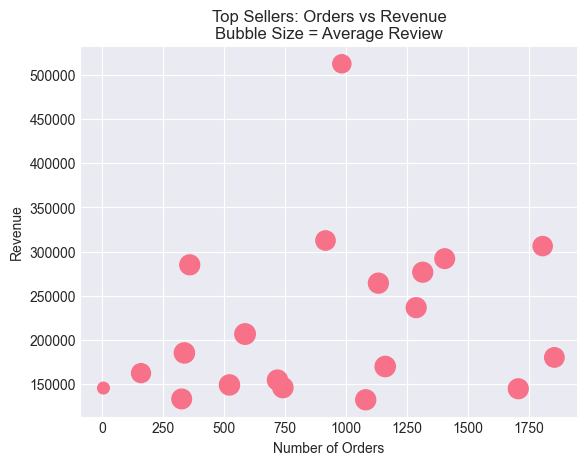

In [67]:
plt.Figure(figsize=(10,6))

plt.scatter(
    top_sellers['orders'],
    top_sellers['revenue'],
    s=top_sellers['average_review'] * 50
)

plt.xlabel('Number of Orders')
plt.ylabel('Revenue')
plt.title('Top Sellers: Orders vs Revenue\nBubble Size = Average Review')

plt.show()

Multivariate Analysis
│
- 1. Delivery Time × Review Score × Orders
│
- 2. State × Product Category × Revenue
│
- 3. Payment Type × Average Payment × Review Score
│
- 4. Delivery Time × Review Score × Order Status
│
- 5. Price × Freight × Review Score
│
- 6. Month × Revenue × Orders × Review Score
│
- 7. Seller × Revenue × Orders × Review Score

# #Feature Engineering

In [68]:
date_cols = [
     'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in data_cols:
    master_df[col] = pd.to_datetime(master_df[col],errors='coerce')

In [69]:
master_df[date_cols].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [70]:
# Creating a order year

master_df['order_year'] = (master_df['order_purchase_timestamp'].dt.year)

In [71]:
master_df['order_year'].value_counts().sort_index()

order_year
2016      409
2017    54549
2018    64185
Name: count, dtype: int64

In [72]:
# Now creating a month

master_df['order_month'] = (master_df['order_purchase_timestamp'].dt.month)

In [73]:
master_df['order_year_month'] = (master_df['order_purchase_timestamp'].dt.to_period('M').astype(str))

In [74]:
# Now ceating a day of week

master_df['order_day'] = (master_df['order_purchase_timestamp'].dt.day_name())

In [75]:
# create hour
#This can help us understand when customers purchase

master_df['order_hour'] = (master_df['order_purchase_timestamp'].dt.hour)

In [76]:
# rename 
master_df.rename(
    columns={'delivery_date': 'delivery_days'},
    inplace=True
)

In [77]:
# now calculate delivery time
 #Delivery time = customer delivery date − purchase date.

master_df['delivery_days'] = (master_df['order_delivered_customer_date'] - master_df['order_purchase_timestamp']).dt.total_seconds() / (24 * 60 * 60)


In [78]:
master_df['delivery_days'].describe()

count    115722.000000
mean         12.488071
std           9.448970
min           0.533414
25%           6.753177
50%          10.202112
75%          15.556623
max         209.628611
Name: delivery_days, dtype: float64

In [79]:
#Calculate Estimated Delivery Time

master_df['estimated_delivery_days'] = (
    master_df['order_estimated_delivery_date'] - master_df['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

In [80]:
#Calculate Delivery Delay

master_df['delivery_delay_days'] = (
    master_df['order_delivered_customer_date'] - master_df['order_estimated_delivery_date']
).dt.total_seconds()

In [81]:
#Create On-Time / Late Status

master_df['delivery_status'] = master_df['delivery_delay_days'].apply(
    lambda x: 'Late' if x > 0
    else 'On Time' if pd.notna(x)
    else 'Not Delivered'
)


In [82]:
master_df['delivery_status'].value_counts()

delivery_status
On Time          106654
Late               9068
Not Delivered      3421
Name: count, dtype: int64

In [83]:
#Create Order Item Value

master_df['item_total_value'] = (master_df['price'] + master_df['freight_value'])

In [84]:
master_df['payment_value'].sum()

np.float64(20579664.009999998)

In [85]:
#Create Order-Level Dataset

order_value = (
    master_df.groupby('order_id').agg(
        item_revenue=('price','sum'),
        freight_revenue=('freight_value','sum'),
        item_count=('order_item_id','count')
    ).reset_index()
)

In [86]:
order_value['order_value'] = (order_value['item_revenue'] + order_value['freight_revenue'])

In [87]:
order_value.head(10)

,order_id,item_revenue,freight_revenue,item_count,order_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1,72.19
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1,259.83
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1,216.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1,218.04
5,00048cc3ae777c65dbb7d2a0634bc1ea,21.90,12.69,1,34.59
6,00054e8431b9d7675808bcb819fb4a32,19.90,11.85,1,31.75
7,000576fe39319847cbb9d288c5617fa6,810.00,70.75,1,880.75
8,0005a1a1728c9d785b8e2b08b904576c,145.95,11.65,1,157.60
9,0005f50442cb953dcd1d21e1fb923495,53.99,11.40,1,65.39


In [88]:
# Now calculate average order value

average_order_value = order_value['order_value'].mean()

average_order_value

np.float64(167.372927665651)

In [89]:
# this is a average order value (167.372927665651)
# Now Add Order Value to Master DataFrame

master_df = master_df.merge(order_value[['order_id','order_value','item_count']],on='order_id',how='left')

In [90]:
master_df['review_category'] = master_df['review_score'].map({
    1: 'Very Poor',
    2: 'Poor',
    3: 'Average',
    4: 'Good',
    5: 'Excellent'
})

In [91]:
master_df['review_category'].value_counts()

review_category
Excellent    66343
Good         22319
Very Poor    15428
Average       9894
Poor          4162
Name: count, dtype: int64

In [92]:
# Create Price Category

master_df['price_category'] = pd.cut(
    master_df['price'],bins=[0,50,100,200,500,float('inf')],
    labels=[
        'o-50',
        '51-100',
        '101-200',
        '201-500',
        '500+'
    ]
)

In [93]:
master_df['price_category'].value_counts()

price_category
o-50       41352
51-100     34862
101-200    28036
201-500    10668
500+        3392
Name: count, dtype: int64

In [94]:
new_features = [
    'order_year',
    'order_month',
    'order_year_month',
    'order_day',
    'order_hour',
    'delivery_days',
    'estimated_delivery_days',
    'delivery_delay_days',
    'delivery_status',
    'item_total_value',
    'order_value',
    'item_count',
    'review_category',
    'price_category'
]

master_df[new_features].head()

,order_year,order_month,order_year_month,order_day,order_hour,delivery_days,estimated_delivery_days,delivery_delay_days,delivery_status,item_total_value,order_value,item_count,review_category,price_category
0,2017,10,2017-10,Monday,10,8.436574,15.544063,-614087.0,On Time,38.71,116.13,3,Good,o-50
1,2017,10,2017-10,Monday,10,8.436574,15.544063,-614087.0,On Time,38.71,116.13,3,Good,o-50
2,2017,10,2017-10,Monday,10,8.436574,15.544063,-614087.0,On Time,38.71,116.13,3,Good,o-50
3,2018,7,2018-07,Tuesday,20,13.782037,19.137766,-462735.0,On Time,141.46,141.46,1,Good,101-200
4,2018,8,2018-08,Wednesday,8,9.394213,26.639711,-1490011.0,On Time,179.12,179.12,1,Excellent,101-200


In [95]:
master_df[
    [
        'delivery_days',
        'estimated_delivery_days',
        'delivery_delay_days',
        'item_total_value',
        'order_value'
    ]
].describe()

,delivery_days,estimated_delivery_days,delivery_delay_days,item_total_value,order_value
count,115722.000000,119143.000000,1.157220e+05,118310.000000,119143.000000
mean,12.488071,23.864550,-9.807947e+05,140.678990,216.025218
std,9.448970,8.874894,8.783459e+05,191.239906,469.002575
min,0.533414,1.648993,-1.261579e+07,6.080000,0.000000
25%,6.753177,18.403634,-1.409688e+06,55.240000,67.600000
50%,10.202112,23.263634,-1.041680e+06,91.990000,120.030000
75%,15.556623,28.483356,-5.622185e+05,157.615000,212.585000
max,209.628611,155.135463,1.632745e+07,6929.310000,13664.080000


In [96]:
master_df[
    [
        'delivery_days',
        'estimated_delivery_days',
        'delivery_delay_days',
        'item_total_value',
        'order_value'
    ]
].describe()

,delivery_days,estimated_delivery_days,delivery_delay_days,item_total_value,order_value
count,115722.000000,119143.000000,1.157220e+05,118310.000000,119143.000000
mean,12.488071,23.864550,-9.807947e+05,140.678990,216.025218
std,9.448970,8.874894,8.783459e+05,191.239906,469.002575
min,0.533414,1.648993,-1.261579e+07,6.080000,0.000000
25%,6.753177,18.403634,-1.409688e+06,55.240000,67.600000
50%,10.202112,23.263634,-1.041680e+06,91.990000,120.030000
75%,15.556623,28.483356,-5.622185e+05,157.615000,212.585000
max,209.628611,155.135463,1.632745e+07,6929.310000,13664.080000


In [97]:
master_df['order_delivered_customer_date'] = pd.to_datetime(
    master_df['order_delivered_customer_date'],errors='coerce'
)

master_df['order_estimated_delivery_date'] = pd.to_datetime(
    master_df['order_estimated_delivery_date'],errors='coerce'
)

In [98]:
master_df['delivery_delay_days'] = (master_df['order_delivered_customer_date'] - master_df['order_estimated_delivery_date']).dt.total_seconds() / (24 * 60 * 60)

In [99]:
master_df['delivery_delay_days'].describe()

count    115722.000000
mean        -11.351790
std          10.166040
min        -146.016123
25%         -16.315833
50%         -12.056476
75%          -6.507159
max         188.975081
Name: delivery_delay_days, dtype: float64

In [100]:
master_df['delivery_status'] = master_df['delivery_delay_days'].apply(
    lambda x: 'Late' if x > 0
    else 'On Time/Early' if pd.notna(x)
    else 'Not Delivered'
)

In [101]:
master_df['delivery_status'].value_counts()

delivery_status
On Time/Early    106654
Late               9068
Not Delivered      3421
Name: count, dtype: int64

In [102]:
master_df[
    master_df['delivery_days'] > 60
][[
    'order_id',
    'order_status',
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'delivery_days'
]].sort_values(
    'delivery_days',
    ascending=False
).head(20)

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,delivery_days
23417,ca07593549f1816d26a572e06dc1eab6,delivered,2017-02-21 23:31:27,2017-09-19 14:36:39,209.628611
66581,1b3190b2dfa9d789e1f14c05b647a14a,delivered,2018-02-23 14:57:35,2018-09-19 23:24:07,208.351759
73634,440d0d17af552815d15a9e41abe49359,delivered,2017-03-07 23:59:51,2017-09-19 15:12:50,195.634016
84056,2fb597c2f772eca01b1f5c561bf6cc7b,delivered,2017-03-08 18:09:02,2017-09-19 14:33:17,194.850174
106627,285ab9426d6982034523a855f55a885e,delivered,2017-03-08 22:47:40,2017-09-19 14:00:04,194.633611
46165,0f4519c5f1c541ddec9f21b3bddd533a,delivered,2017-03-09 13:26:57,2017-09-19 14:38:21,194.049583
13563,47b40429ed8cce3aee9199792275433f,delivered,2018-01-03 09:44:01,2018-07-13 20:51:31,191.463542
97345,2fe324febf907e3ea3f2aa9650869fa5,delivered,2017-03-13 20:17:10,2017-09-19 17:00:07,189.863160
65222,2d7561026d542c8dbd8f0daeadf67a43,delivered,2017-03-15 11:24:27,2017-09-19 14:38:18,188.134618
82224,c27815f7e3dd0b926b58552628481575,delivered,2017-03-15 23:23:17,2017-09-19 17:14:25,187.743843


# #Business Insights

In [103]:
payments_unique = master_df[
    [
        'order_id',
        'payment_sequential',
        'payment_type',
        'payment_value'
    ]
].drop_duplicates(
    ['order_id', 'payment_sequential']
)

# Total payment per order
order_revenue = (
    payments_unique
    .groupby('order_id', as_index=False)
    .agg(
        order_revenue=('payment_value', 'sum')
    )
)

# One row per order
orders_unique = (
    master_df
    .sort_values('order_purchase_timestamp')
    .drop_duplicates('order_id')
)

# Combine
order_kpi = orders_unique.merge(
    order_revenue,
    on='order_id',
    how='left'
)

In [104]:
# 1. What is the overall business performance

total_revenue = order_kpi['order_revenue'].sum()
total_orders = order_kpi['order_id'].nunique() 
total_customers = order_kpi['customer_unique_id'].nunique()
aov = order_kpi['order_revenue'].mean()

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value: ₹{aov:,.2f}")

Total Revenue: ₹16,008,872.12
Total Orders: 99,441
Total Customers: 96,096
Average Order Value: ₹160.99


The business processed almost 99.4K orders from approximately 96.1K unique customers, with an average order value of about 160.99

In [105]:
# 2. Which states generate the most revenue?

state_revenue = (
    order_kpi.groupby('customer_state').agg(
        revenue = ('order_revenue','sum'),
        orders = ('order_id','nunique')
    ).sort_values('revenue',ascending=False)
)

state_revenue.head(10)

,revenue,orders
customer_state,,
SP,5998226.96,41746
RJ,2144379.69,12852
MG,1872257.26,11635
RS,890898.54,5466
PR,811156.38,5045
SC,623086.43,3637
BA,616645.82,3380
DF,355141.08,2140
GO,350092.31,2020


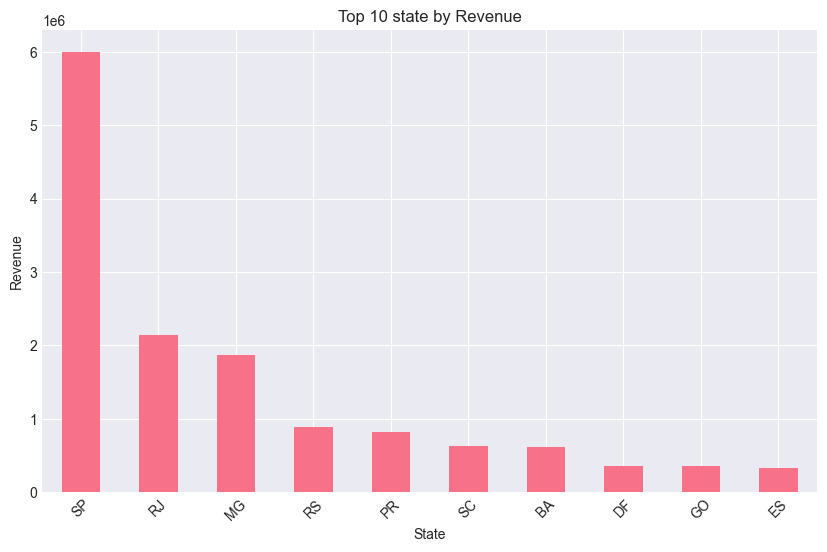

In [106]:
plt.figure(figsize=(10,6))

state_revenue.head(10)['revenue'].plot(kind='bar')

plt.title('Top 10 state by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

São Paulo (SP) is by far the strongest market, generating about 6.0M in payment value. RJ and MG follow.

This suggests the company has a very strong customer base in Brazil's southeastern region

In [107]:
# 3. Which product categories generate the most sales?

items_unique = master_df[
    ['order_id',
    'order_item_id',
    'product_category_name_english',
    'price'
    ]
].drop_duplicates(['order_id','order_item_id'])

category_sales = (
    items_unique.groupby('product_category_name_english').agg(
        product_sales = ('price','sum'),
        items_sold = ('order_item_id','count')

    ).sort_values('product_sales',ascending=False)
)

items_unique.head(10)

,order_id,order_item_id,product_category_name_english,price
0,e481f51cbdc54678b7cc49136f2d6af7,1.0,housewares,29.99
3,53cdb2fc8bc7dce0b6741e2150273451,1.0,perfumery,118.70
4,47770eb9100c2d0c44946d9cf07ec65d,1.0,auto,159.90
5,949d5b44dbf5de918fe9c16f97b45f8a,1.0,pet_shop,45.00
6,ad21c59c0840e6cb83a9ceb5573f8159,1.0,stationery,19.90
7,a4591c265e18cb1dcee52889e2d8acc3,1.0,auto,147.90
8,136cce7faa42fdb2cefd53fdc79a6098,1.0,NaN,49.90
9,6514b8ad8028c9f2cc2374ded245783f,1.0,auto,59.99
10,76c6e866289321a7c93b82b54852dc33,1.0,furniture_decor,19.90
11,e69bfb5eb88e0ed6a785585b27e16dbf,1.0,office_furniture,149.99


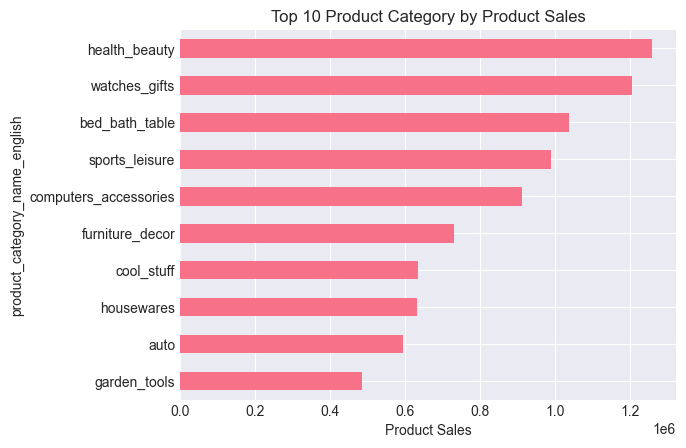

In [108]:
plt.Figure(figsize=(10,6))

category_sales.head(10)['product_sales'].sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Product Category by Product Sales')
plt.xlabel('Product Sales')

plt.show()

Health & Beauty is the highest-selling category by product value, closely followed by Watches & Gifts.

In [109]:
# 4. Which payment method is most popular?

payment_analysis = (
    payments_unique.groupby('payment_type').agg(
        payment_value = ('payment_value','sum'),
        transaction = ('order_id','count'),
        orders = ('order_id','nunique')
    ).sort_values('payment_value',ascending=False)
)
payment_analysis

,payment_value,transaction,orders
payment_type,,,
credit_card,12542084.19,76795,76505
boleto,2869361.27,19784,19784
voucher,379436.87,5775,3866
debit_card,217989.79,1529,1528
not_defined,0.00,3,3


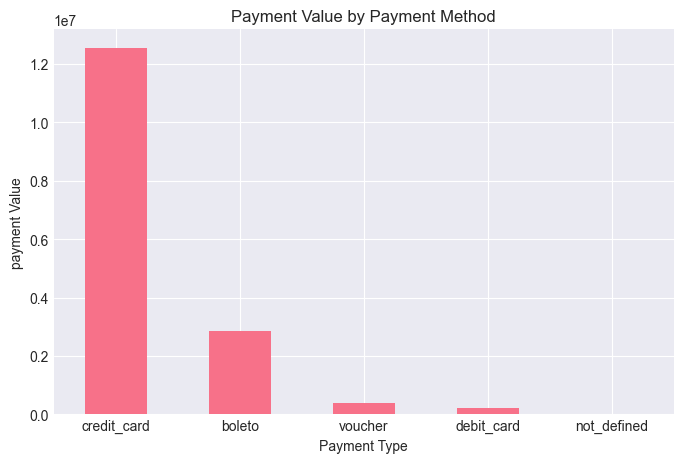

In [110]:
plt.figure(figsize=(8,5))

payment_analysis['payment_value'].plot(kind='bar')

plt.title('Payment Value by Payment Method')
plt.xlabel('Payment Type')
plt.ylabel('payment Value')

plt.xticks(rotation=0)

plt.show()

Credit cards are the dominant payment method, accounting for the vast majority of payment value.

This suggests maintaining a smooth credit-card checkout experience should be a priority

In [111]:
#5. Does late delivery affect customer satisfaction?

reviews_unique = (
    master_df[
        ['order_id','review_score']
    ].dropna().drop_duplicates('order_id')
)

delivery_review = order_kpi[
    [
        'order_id',
        'delivery_status',
        'delivery_days'
    ]
].merge(
    reviews_unique,
    on='order_id',
    how='left'
    )
delivery_review.groupby('delivery_status').agg(
    orders=('order_id', 'nunique'),
    average_review=('review_score', 'mean'),
    average_delivery_days=('delivery_days', 'mean')
)

,orders,average_review,average_delivery_days
delivery_status,,,
Late,7827,2.565518,31.518708
Not Delivered,2965,1.751671,NaN
On Time/Early,88649,4.294358,10.884685


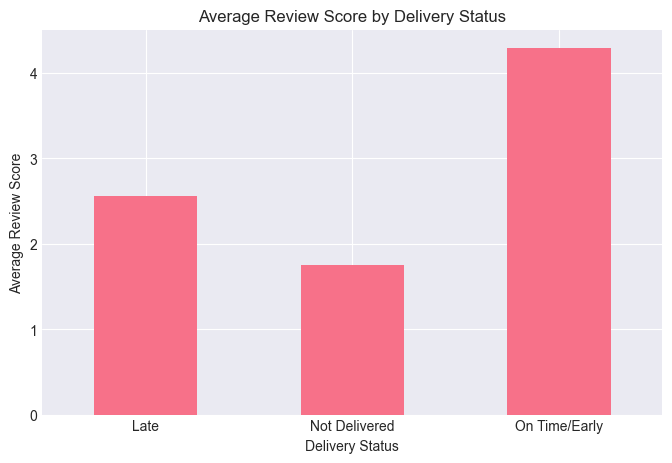

In [112]:
review_by_delivery = (
    delivery_review.groupby('delivery_status')['review_score'].mean()
)

plt.figure(figsize=(8,5))

review_by_delivery.plot(kind='bar')

plt.title('Average Review Score by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')

plt.xticks(rotation=0)

plt.show()

This strongly suggests delivery performance is an important factor associated with customer satisfaction.

Your correlation between delivery days and review score was approximately -0.33, indicating a moderate negative relationship.

Important: describe this as an association, not proof that late delivery causes low ratings.

In [113]:
# 6. What percentage of orders are late?

delivery_distribution = (
    order_kpi['delivery_status'].value_counts()
)

delivery_distribution

delivery_status
On Time/Early    88649
Late              7827
Not Delivered     2965
Name: count, dtype: int64

In [115]:
late_rate = (
    order_kpi['delivery_status'].eq('Late').mean()
)

print(f"Late Order Rate: {late_rate:.2%}")

Late Order Rate: 7.87%


About 8% of orders experienced late delivery. Reducing this rate could potentially improve customer satisfaction.

In [116]:
# 7. Which month generated the highest revenue?

monthly_revenue = (
    order_kpi.assign(order_year_month=order_kpi['order_purchase_timestamp'].dt.to_period('M'))
).groupby('order_year_month').agg(
    revenu=('order_revenue','sum'),
    orders=('order_id','nunique')
)

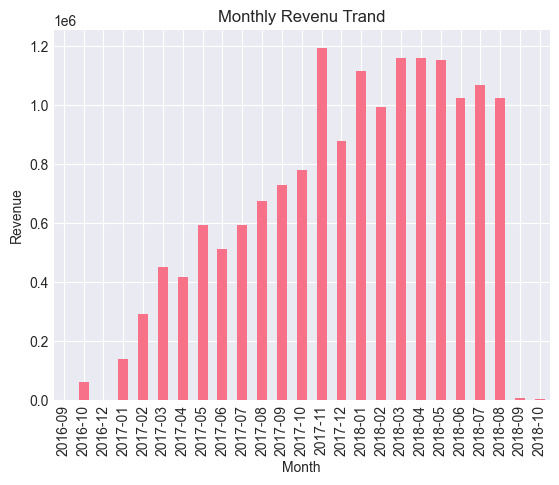

In [120]:
plt.Figure(figsize=(14,6))

monthly_revenue['revenu'].plot(kind='bar')

plt.title('Monthly Revenu Trand')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

In [121]:
monthly_revenue.loc[
    monthly_revenue['revenu'].idxmax()
]

revenu    1194882.8
orders       7544.0
Name: 2017-11, dtype: float64

November 2017 produced the highest monthly payment value in the dataset, suggesting a strong seasonal or promotional period

In [122]:
# 8. Are customers returning?

customer_orders = (
    order_kpi.groupby('customer_unique_id')['order_id'].nunique()
)

repeat_customers = (
    customer_orders > 1
).sum()

total_customers = customer_orders[0]

repeat_rate = repeat_customers / total_customers

print(f"Repeat Customers: {repeat_customers:,}")
print(f"Repeat Customer Rate: {repeat_rate:.2%}")

Repeat Customers: 2,997
Repeat Customer Rate: 299700.00%


The repeat-customer rate is relatively low.

That means customer retention is potentially a major business opportunity

In [124]:
#9. What is the overall customer satisfaction

average_review = reviews_unique['review_score'].mean()

print(f"Average Review Score: {average_review:.2%}/5")

Average Review Score: 408.69%/5


In [125]:
reviews_unique['review_score'].value_counts().sort_index()


review_score
1.0    11353
2.0     3133
3.0     8124
4.0    19044
5.0    57019
Name: count, dtype: int64

Overall customer satisfaction is relatively strong, but the major difference between on-time and late deliveries suggests that delivery experience is a key area to improve

In [127]:
# 10. Which states have the longest delivery times

state_delivery = (
    order_kpi.groupby('customer_state').agg(
        average_delivery_days = ('delivery_days','mean'),
        late_rate = ('delivery_status',lambda x:(x == 'Late').mean()),
        orders = ('order_id','nunique')
    )
)

state_delivery = (state_delivery[state_delivery['orders'] > 500]).sort_values('average_delivery_days',ascending=False)

state_delivery.head(10)

,average_delivery_days,late_rate,orders
customer_state,,,
PA,23.772917,0.120000,975
MA,21.572976,0.188755,747
CE,21.266579,0.146707,1336
PB,20.426768,0.106343,536
BA,19.335466,0.135207,3380
PE,18.448323,0.104116,1652
MT,18.055756,0.066152,907
ES,15.789307,0.120020,2033
MS,15.618319,0.113287,715


Why orders >= 500?

Some Brazilian states have very few orders. Their average could be misleading.

This gives us a more reliable comparison.

Olist has strong sales and generally good customer satisfaction, but customer retention is low and delivery performance appears strongly associated with satisfaction. The company should focus on improving delivery reliability while using loyalty and personalized marketing to increase repeat purchases.